# Implement Stochastic Gradient Descent (SGD) from scratch with the Negative Log-Likelihood (NLL) objective and analytic derivatives to optimize the parameters.

## Functions given:

Responsibility function for component $k$ and data point $i$:
$$
\gamma_{ik} =
\frac{ \pi_k \, \mathcal{N}(x_i \mid \mu_k, \Sigma_k) }
     { \sum_{j=1}^K \pi_j \, \mathcal{N}(x_i \mid \mu_j, \Sigma_j) }.
     $$

Mean gradient(for a mini-batch $B$):
$$\frac{\partial \mathcal{L}_B}{\partial \mu_k}
= \sum_{i \in B} \gamma_{ik} \, \Sigma_k^{-1} (x_i - \mu_k).$$

Variance gradient(for diagonal covariance matrices): $$\frac{\partial \mathcal{L}_B}{\partial \log \sigma_{kd}^2}
= \frac{1}{2} \sum_{i \in B} \gamma_{ik}
  \left[ \frac{(x_{id} - \mu_{kd})^2}{\sigma_{kd}^2} - 1 \right],$$ where $d$ indexes the feature dimension.

Mixture weights gradient(with softmax re-parameterization):
$$
\frac{\partial \mathcal{L}_B}{\partial \pi_k}
= \sum_{i \in B} \frac{\gamma_{ik}}{\pi_k}.$$

Gradient functions can be found in def compute_gradient and responsibility function can be found in compute_responsibility

## Data generation:

In [312]:
# Set device
# Ensure GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

import torch
import torch.distributions as dist
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import linear_sum_assignment

Using device: cuda


In [313]:
# Step 1: Setup parameters for 3-Component, 3-Feature MoG
torch.manual_seed(42)
np.random.seed(42)

# Requirements: 3 components, 3 features
m = 1000  # 1000 sample points
feature_dims = 3  # 3 feature dimensions (x, y, z) - CHANGED from 2 in part 1
n_components = 3  # Number of Gaussian components

# Mixing weights - can be uniform or non-uniform
mixing_weights = torch.ones(n_components) / n_components  # Uniform: [1/3, 1/3, 1/3]
# Alternatively: mixing_weights = torch.tensor([0.3, 0.4, 0.3])

# Generate well-separated means for better visualization and learning
means = torch.tensor(
    [
        [0.0, 0.0, 0.0],  # Component 1: near origin
        [3.0, -2.0, 1.0],  # Component 2: separated in space
        [-1.5, 2.5, -2.0],  # Component 3: well separated
    ],
    dtype=torch.float32,
)

# Define diagonal covariance values for each component and feature
# Assignment specifies diagonal covariance matrices
covariance_diagonals = torch.tensor(
    [
        [0.5, 0.5, 0.5],  # Component 1: moderate spread
        [1.5, 2.0, 2.5],  # Component 2: higher spread
        [0.25, 1.0, 0.25],  # Component 3: different spread pattern
    ],
    dtype=torch.float32,
)

# Convert diagonal values to full covariance matrices (zeros off-diagonal)
covariances = torch.zeros(n_components, feature_dims, feature_dims)
for i in range(n_components):
    covariances[i] = torch.diag(covariance_diagonals[i])

print("3-Component, 3-Feature MoG Parameters:")
print(f"Mixing weights: {mixing_weights}")
print(f"Means:\n{means}")
print(f"Covariance diagonals:\n{covariance_diagonals}")
print(f"Full covariances:\n{covariances}")

3-Component, 3-Feature MoG Parameters:
Mixing weights: tensor([0.3333, 0.3333, 0.3333])
Means:
tensor([[ 0.0000,  0.0000,  0.0000],
        [ 3.0000, -2.0000,  1.0000],
        [-1.5000,  2.5000, -2.0000]])
Covariance diagonals:
tensor([[0.5000, 0.5000, 0.5000],
        [1.5000, 2.0000, 2.5000],
        [0.2500, 1.0000, 0.2500]])
Full covariances:
tensor([[[0.5000, 0.0000, 0.0000],
         [0.0000, 0.5000, 0.0000],
         [0.0000, 0.0000, 0.5000]],

        [[1.5000, 0.0000, 0.0000],
         [0.0000, 2.0000, 0.0000],
         [0.0000, 0.0000, 2.5000]],

        [[0.2500, 0.0000, 0.0000],
         [0.0000, 1.0000, 0.0000],
         [0.0000, 0.0000, 0.2500]]])


In [314]:
# Step 2: Create PyTorch distributions
def create_mixture_distributions(means, covariances, mixing_weights):
    """Create PyTorch distribution objects for the mixture"""

    # Create individual multivariate normal distributions
    components = []
    for i in range(len(means)):
        component = dist.MultivariateNormal(means[i], covariances[i])
        components.append(component)

    # Create categorical distribution for component selection
    component_dist = dist.Categorical(mixing_weights)

    return components, component_dist


# Create the distributions
components, component_dist = create_mixture_distributions(means, covariances, mixing_weights)

In [315]:
# Step 3: Generate the dataset using PyTorch sampling
def sample_from_mixture(m, components, component_dist):
    """Sample from mixture of Gaussians using PyTorch"""

    # Sample which component each data point comes from
    component_indices = component_dist.sample((m,))

    # Initialize output tensors for 3D data
    samples = torch.zeros(m, feature_dims)

    # Sample from each component
    for i in range(len(components)):
        # Find which samples should come from component i
        mask = component_indices == i
        n_from_component = mask.sum().item()
        print(f"Component {i}: {n_from_component} samples")

        if n_from_component > 0:
            # Sample from component i
            component_samples = components[i].sample((n_from_component,))
            samples[mask] = component_samples

    return samples, component_indices


# Generate the dataset
X, y_true = sample_from_mixture(m, components, component_dist)

print(f"\nGenerated 3D dataset:")
print(f"Shape: {X.shape}")  # Should be [1000, 3]
print(f"Data type: {X.dtype}")
print(f"Device: {X.device}")

print(f"\nGround truth component assignments:")
print(f"Shape: {y_true.shape}")
print(f"Component distribution: {torch.bincount(y_true)}")

Component 0: 356 samples
Component 1: 338 samples
Component 2: 306 samples

Generated 3D dataset:
Shape: torch.Size([1000, 3])
Data type: torch.float32
Device: cpu

Ground truth component assignments:
Shape: torch.Size([1000])
Component distribution: tensor([356, 338, 306])


In [316]:
# Step 4: Verify our generation by computing statistics
print(f"\nDataset Statistics:")
print(f"Overall mean: [{X[:, 0].mean():.3f}, {X[:, 1].mean():.3f}]")
print(f"Overall std:  [{X[:, 0].std():.3f}, {X[:, 1].std():.3f}]")

print(f"\nPer-component statistics:")
for i in range(n_components):
    mask = y_true == i
    component_data = X[mask]
    print(f"Component {i}: {mask.sum().item()} samples")
    print(f"  Mean: [{component_data[:, 0].mean():.3f}, {component_data[:, 1].mean():.3f}]")
    print(f"  Std:  [{component_data[:, 0].std():.3f}, {component_data[:, 1].std():.3f}]")


Dataset Statistics:
Overall mean: [0.527, 0.096]
Overall std:  [2.026, 2.093]

Per-component statistics:
Component 0: 356 samples
  Mean: [0.027, 0.001]
  Std:  [0.723, 0.706]
Component 1: 338 samples
  Mean: [2.923, -1.967]
  Std:  [1.227, 1.418]
Component 2: 306 samples
  Mean: [-1.538, 2.486]
  Std:  [0.494, 1.042]


In [317]:
# Step 5: Split into train/test sets
train_ratio = 0.7
train_size = int(train_ratio * m)

# Shuffle indices to ensure random train/test split
indices = torch.randperm(m)
train_indices = indices[:train_size]
test_indices = indices[train_size:]

X_train = X[train_indices]
X_test = X[test_indices]
y_train = y_true[train_indices]
y_test = y_true[test_indices]

print(f"\nTrain/Test Split:")
print(f"Training set: {X_train.shape}")


Train/Test Split:
Training set: torch.Size([700, 3])


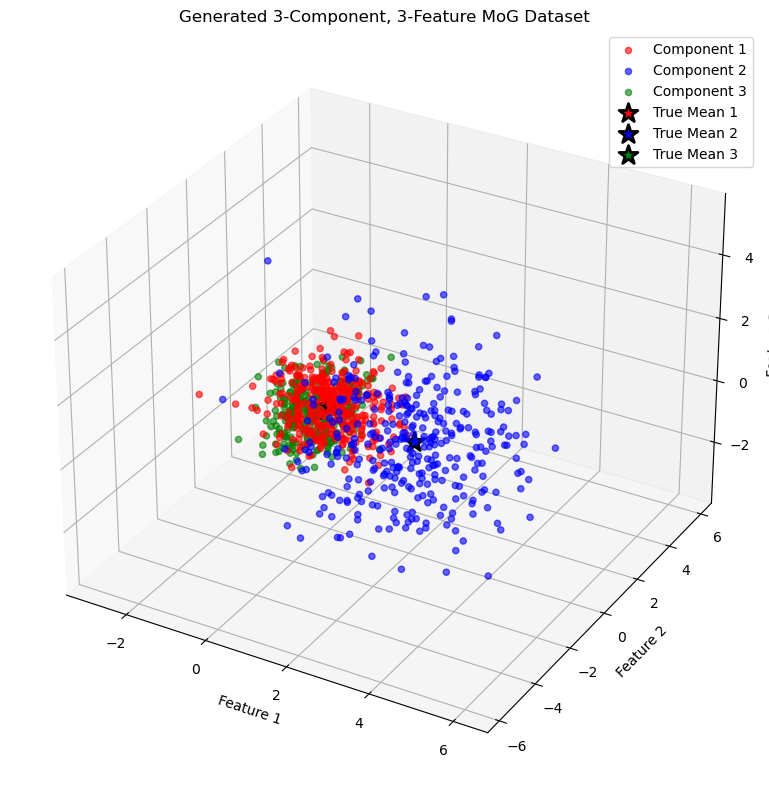

In [318]:
# Step 6: Visualize the 3D data
def plot_3d_mixture(X, y_true, means, title="3-Component, 3-Feature MoG Data"):
    """Plot 3D scatter plot of the mixture data"""
    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(111, projection="3d")

    # Colors for each component
    colors = ["red", "blue", "green"]

    # Plot data points colored by true component
    for i in range(n_components):
        mask = y_true == i
        component_data = X[mask]
        ax.scatter(
            component_data[:, 0],
            component_data[:, 1],
            component_data[:, 2],
            c=colors[i],
            alpha=0.6,
            s=20,
            label=f"Component {i + 1}",
        )

    # Plot true means as large markers
    for i in range(n_components):
        ax.scatter(
            means[i, 0],
            means[i, 1],
            means[i, 2],
            c=colors[i],
            s=200,
            marker="*",
            edgecolor="black",
            linewidth=2,
            label=f"True Mean {i + 1}",
        )

    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")
    ax.set_zlabel("Feature 3")
    ax.set_title(title)
    ax.legend()

    plt.tight_layout()
    plt.show()


# Plot the generated data
plot_3d_mixture(X, y_true, means, "Generated 3-Component, 3-Feature MoG Dataset")

## MOGSGD Implementation

In [ ]:
class MoGSGD:
    def __init__(self, n_components=3, n_features=3, device=None):
        """
        Initialize Mixture of Gaussians with SGD optimization

        Parameters:
        - n_components: Number of Gaussian components (K=3)
        - n_features: Number of features (Dimensions =3)
        - device: PyTorch device for GPU/CPU computation
        """
        self.K = n_components
        self.D = n_features
        self.device = device if device is not None else torch.device("cuda" if torch.cuda.is_available() else "cpu")

        print(f"Using device: {self.device}")

    def initialize_parameters(self, X_train):
        """Initialize MoG parameters using data-driven strategy for better convergence"""
        torch.manual_seed(42)

        X_sample = X_train[: min(500, X_train.shape[0])]  # Use subset for efficiency
        n_samples = X_sample.shape[0]

        # Initialize first center randomly from data
        first_idx = torch.randint(0, n_samples, (1,), device=self.device)
        centers = [X_sample[first_idx].squeeze()]

        # Initialize remaining centers
        for _ in range(self.K - 1):
            # Compute distances to nearest existing center
            distances = torch.stack(
                [torch.sum((X_sample - center.unsqueeze(0)) ** 2, dim=1) for center in centers]
            ).min(dim=0)[0]

            # Sample next center with probability proportional to squared distance
            probs = distances / (distances.sum() + 1e-8)
            next_idx = torch.multinomial(probs, 1)
            centers.append(X_sample[next_idx].squeeze())

        # Set initialized means
        self.mu = torch.stack(centers)

        # Initialize variances based on data statistics
        data_var = torch.var(X_sample, dim=0)
        # Add some component-specific variation to avoid identical variances
        variance_noise = torch.randn(self.K, self.D, device=self.device) * 0.1
        init_variances = data_var.unsqueeze(0).repeat(self.K, 1) * torch.exp(variance_noise)
        self.log_sigma_sq = torch.log(torch.clamp(init_variances, min=0.1, max=10.0))

        # Initialize mixing weights uniformly
        self.log_pi = torch.zeros(self.K, device=self.device, requires_grad=False)

        print("Data-driven initialization completed:")
        print(f"Initial π: {self.get_pi()}")
        print(f"Initial μ:\n{self.mu}")
        print(f"Initial σ²:\n{self.get_sigma_sq()}")
        print(f"Data range: min={X_sample.min(dim=0)[0]}, max={X_sample.max(dim=0)[0]}")
        print(f"Data variance: {data_var}")

    def get_pi(self):
        """Get normalized mixing weights using softmax parameterization"""
        return torch.softmax(self.log_pi, dim=0)

    def get_sigma_sq(self):
        """Get variances using exp parameterization with stability clamping"""
        return torch.exp(torch.clamp(self.log_sigma_sq, min=-10, max=10))

    def multivariate_normal_pdf(self, x, mu_k, sigma_sq_k):
        """
        Compute multivariate normal PDF with diagonal covariance matrices

        For diagonal covariance: Σ_k = diag(σ²_k1, σ²_k2, σ²_k3)

        Parameters:
        - x: (batch_size, D) - input data
        - mu_k: (D,) - mean for component k
        - sigma_sq_k: (D,) - diagonal variances for component k
        """
        diff = x - mu_k.unsqueeze(0)

        # Work in log space for numerical stability
        log_det = torch.sum(torch.log(sigma_sq_k))
        mahalanobis = torch.sum(diff**2 / sigma_sq_k.unsqueeze(0), dim=1)

        log_prob = -0.5 * (self.D * torch.log(torch.tensor(2 * torch.pi, device=self.device)) + log_det + mahalanobis)
        return torch.exp(log_prob)

    def compute_responsibilities(self, X):
        """
        Compute responsibility function gamma_ik with numerical stability

        gamma_ik = (π_k * N(x_i | μ_k, Σ_k)) / (Σ_j π_j * N(x_i | μ_j, Σ_j))

        Parameters:
        - X: (batch_size, D) - input data batch

        Returns:
        - responsibilities: (batch_size, K) - gamma_ik values
        """
        batch_size = X.shape[0]
        pi = self.get_pi() # Mixing weights [π_1, π_2, π_3]
        sigma_sq = self.get_sigma_sq() # Variances for each component

        # Compute log probabilities for numerical stability
        # Gaussian PDF may be very small, working with log will turn multiplication to addition
        # Potentially reduce underflow?

        log_probs = torch.zeros(batch_size, self.K, device=self.device)

        for k in range(self.K):
            diff = X - self.mu[k].unsqueeze(0)
            log_det = torch.sum(torch.log(sigma_sq[k]))
            mahalanobis = torch.sum(diff**2 / sigma_sq[k].unsqueeze(0), dim=1)

            log_probs[:, k] = torch.log(pi[k] + 1e-8) - 0.5 * (
                self.D * torch.log(torch.tensor(2 * torch.pi, device=self.device)) + log_det + mahalanobis
            )

        # Use log-sum-exp trick for numerical stability
        # Applying exp() to very small number may cause underflow

        max_log_prob = torch.max(log_probs, dim=1, keepdim=True)[0]
        log_probs_shifted = log_probs - max_log_prob

        # Convert back to probabilities and normalize
        # Normalized so each row is summed to 1
        probs = torch.exp(log_probs_shifted)
        total_prob = torch.sum(probs, dim=1, keepdim=True)
        responsibilities = probs / (total_prob + 1e-8)

        return responsibilities

    def negative_log_likelihood(self, X):
        """
        Compute negative log-likelihood for the batch

        NLL = -Σ_i log(Σ_k π_k * N(x_i | μ_k, Σ_k))

        Parameters:
        - X: (batch_size, D) - input data

        Returns:
        - nll: scalar - average negative log-likelihood
        """
        batch_size = X.shape[0]
        pi = self.get_pi()
        sigma_sq = self.get_sigma_sq()

        # Compute log probabilities for all components
        log_probs = torch.zeros(batch_size, self.K, device=self.device)

        for k in range(self.K):
            # Using the log trick to avoid underflow
            diff = X - self.mu[k].unsqueeze(0)
            log_det = torch.sum(torch.log(sigma_sq[k])) # The larger log_det, the more "spread out" our distribution
            # Mahalanobis distance measures how far a data point is from the mean of a distribution, 
            # accounting for the covariance structure.
            mahalanobis = torch.sum(diff**2 / sigma_sq[k].unsqueeze(0), dim=1)

            log_probs[:, k] = torch.log(pi[k]) - 0.5 * (
                self.D * torch.log(torch.tensor(2 * torch.pi, device=self.device)) + log_det + mahalanobis
            )

        # Use log-sum-exp trick for numerical stability
        max_log_prob = torch.max(log_probs, dim=1, keepdim=True)[0]
        log_sum_exp = max_log_prob + torch.log(torch.sum(torch.exp(log_probs - max_log_prob), dim=1, keepdim=True))

        return -torch.mean(log_sum_exp)

    def compute_gradients(self, X_batch):
        """
        Compute analytical gradients using the mathematical formulas:
        1. Mean gradient: ∂L/∂μ_k = Σ_i γ_ik * Σ_k^(-1) * (x_i - μ_k)
        2. Variance gradient: ∂L/∂log(σ²_kd) = (1/2) * Σ_i γ_ik * [(x_id - μ_kd)²/σ²_kd - 1]
        3. Mixture weights: ∂L/∂π_k = Σ_i γ_ik / π_k (with softmax chain rule)

        Parameters:
        - X_batch: (batch_size, D) - mini-batch data

        Returns:
        - grad_mu: (K, D) - mean gradients
        - grad_log_sigma_sq: (K, D) - log-variance gradients
        - grad_log_pi: (K,) - log-mixture weight gradients
        """
        batch_size = X_batch.shape[0]
        responsibilities = self.compute_responsibilities(X_batch)

        pi = self.get_pi()
        sigma_sq = self.get_sigma_sq()

        # Initialize gradients
        grad_mu = torch.zeros_like(self.mu)
        grad_log_sigma_sq = torch.zeros_like(self.log_sigma_sq)
        grad_log_pi = torch.zeros_like(self.log_pi)

        # Compute gradients for each component k
        for k in range(self.K):
            # Mean gradient: ∂L/∂μ_k = Σ_i γ_ik * Σ_k^(-1) * (x_i - μ_k)
            for d in range(self.D):
                grad_mu[k, d] = torch.sum(responsibilities[:, k] * (X_batch[:, d] - self.mu[k, d]) / sigma_sq[k, d])

            # Variance gradient: ∂L/∂log(σ²_kd) = (1/2) * Σ_i γ_ik * [(x_id - μ_kd)²/σ²_kd - 1]
            for d in range(self.D):
                diff_sq = (X_batch[:, d] - self.mu[k, d]) ** 2
                grad_log_sigma_sq[k, d] = 0.5 * torch.sum(responsibilities[:, k] * (diff_sq / sigma_sq[k, d] - 1))

        # Mixture weights gradient with softmax re-parameterization
        # If we decrease π_k directly, how much of an impact does it have on loss?
        grad_pi_direct = torch.zeros(self.K, device=self.device)
        for k in range(self.K):
            grad_pi_direct[k] = torch.sum(responsibilities[:, k]) / pi[k]  # ∂L/∂π_k = Σ_i γ_ik / π_k

        # Not optimizing π_k directly, instead use log π_k
        for k in range(self.K):
            # grad_log_pi[k] = local change - global change
            grad_log_pi[k] = grad_pi_direct[k] * pi[k] - torch.sum(grad_pi_direct * pi) * pi[k]

        return grad_mu, grad_log_sigma_sq, grad_log_pi

    def sgd_step(self, X_batch, learning_rate):
        """
        Perform one SGD step with analytical gradients

        Parameters:
        - X_batch: (batch_size, D) - mini-batch data
        - learning_rate: float - step size for gradient descent
        """
        grad_mu, grad_log_sigma_sq, grad_log_pi = self.compute_gradients(X_batch)

        # Gradient clipping for numerical stability
        grad_mu = torch.clamp(grad_mu, min=-10, max=10)
        grad_log_sigma_sq = torch.clamp(grad_log_sigma_sq, min=-5, max=5)
        grad_log_pi = torch.clamp(grad_log_pi, min=-10, max=10)

        # SGD parameter updates:
        self.mu += learning_rate * grad_mu
        self.log_sigma_sq += learning_rate * grad_log_sigma_sq
        self.log_pi += learning_rate * grad_log_pi

        # Limit parameters to reasonable ranges for stability
        self.mu = torch.clamp(self.mu, min=-10, max=10)
        self.log_sigma_sq = torch.clamp(self.log_sigma_sq, min=-10, max=10)
        self.log_pi = torch.clamp(self.log_pi, min=-10, max=10)

    def fit(self, X_train, X_test, learning_rate=0.001, epochs=1000, batch_size=32):
        """
        Fit MoG using SGD with analytical gradients

        Parameters:
        - X_train: (N_train, D) - training data
        - X_test: (N_test, D) - test data
        - learning_rate: float - SGD learning rate
        - epochs: int - number of training epochs
        - batch_size: int - mini-batch size

        Returns:
        - train_losses: list - training NLL over epochs
        - test_losses: list - test NLL over epochs
        """
        # Ensure data is on correct device
        X_train = X_train.to(self.device)
        X_test = X_test.to(self.device)

        n_samples = X_train.shape[0]
        train_losses = []
        test_losses = []

        print(f"Starting SGD training for {epochs} epochs...")
        print(f"Data shapes: X_train {X_train.shape}, X_test {X_test.shape}")
        print(f"Batch size: {batch_size}, Learning rate: {learning_rate}")

        # An epoch is one complete pass over the training data
        for epoch in range(epochs):
            # Shuffle data for each epoch to benefit SGD in seeing the data in different order
            indices = torch.randperm(n_samples, device=self.device)
            X_shuffled = X_train[indices]

            # Mini-batch SGD
            # Split the training samples into batches of 64
            # Why 64? I looked online and it typically is a power of 2.
            # This probably has to do with how memory is organized(power of 2).
            # Also benefits parallelization
            for i in range(0, n_samples, batch_size):
                batch_end = min(i + batch_size, n_samples)
                X_batch = X_shuffled[i:batch_end]
                # Each batchi triggers one gradient computation and parameter update
                self.sgd_step(X_batch, learning_rate)

            # Compute and store losses every 10 epochs since it is expensive
            if epoch % 10 == 0:
                with torch.no_grad():
                    train_loss = self.negative_log_likelihood(X_train).item()
                    test_loss = self.negative_log_likelihood(X_test).item()
                    train_losses.append(train_loss)
                    test_losses.append(test_loss)
                # Large gap between train NLL and test NLL means overfitting,
                # however I am not entirely sure that my results are indicative of that.
                if epoch % 100 == 0:
                    print(f"Epoch {epoch:4d}: Train NLL = {train_loss:.4f}, Test NLL = {test_loss:.4f}")

        print("Training completed!")
        return train_losses, test_losses

    def find_best_component_matching(self, true_means):
        """
        Attempt to solve the label switching problem
        True components might be:
        True Component 0: mean = [0, 0, 0]
        True Component 1: mean = [3, -2, 1] 
        True Component 2: mean = [-1.5, 2.5, -2]

        SGD may learn them as:
        Learned Component 0: mean = [3.1, -1.9, 0.9]    # Actually corresponds to True Component 1
        Learned Component 1: mean = [-1.4, 2.6, -1.8]   # Actually corresponds to True Component 2  
        Learned Component 2: mean = [0.1, -0.1, 0.2]    # Actually corresponds to True Component 0
        
        """
        
        learned_means = self.mu.detach().cpu().numpy()
        true_means_np = true_means.cpu().numpy()

        # Compute pairwise distances between all learned and true components
        cost_matrix = np.zeros((self.K, self.K))
        for i in range(self.K):
            for j in range(self.K):
                cost_matrix[i, j] = np.sum((learned_means[i] - true_means_np[j]) ** 2)
        '''
        Cost matrix may look like
                    True 0    True 1    True 2
            Learned 0  [[   5.2,      0.1,      8.7  ],
            Learned 1   [   7.3,      6.8,      0.2  ],
            Learned 2   [   0.05,     9.1,      7.5  ]]
        '''
        # Find optimal assignment by minimizing the cost
        learned_idx, true_idx = linear_sum_assignment(cost_matrix)

        return learned_idx, true_idx

    def compare_with_true_parameters(self, true_mixing_weights, true_means, true_covariance_diagonals):
        """Compare with component matching"""
        print("\n" + "=" * 60)
        print("PARAMETER COMPARISON")
        print("=" * 60)

        # Find best component matching, potentially changing the label
        learned_idx, true_idx = self.find_best_component_matching(true_means)

        # Reorder learned parameters to match true parameters
        learned_pi_matched = self.get_pi().detach()[learned_idx]
        learned_mu_matched = self.mu.detach()[learned_idx]
        learned_sigma_matched = self.get_sigma_sq().detach()[learned_idx]

        # Reorder true parameters accordingly
        true_pi_matched = true_mixing_weights[true_idx]
        true_mu_matched = true_means[true_idx]
        true_sigma_matched = true_covariance_diagonals[true_idx]

        print(f"Component matching: Learned {learned_idx} -> True {true_idx}")

        # We compute metrics with proper alignment
        pi_mse = torch.mean((learned_pi_matched - true_pi_matched) ** 2).item()
        mu_mse = torch.mean((learned_mu_matched - true_mu_matched) ** 2).item()
        sigma_mse = torch.mean((learned_sigma_matched - true_sigma_matched) ** 2).item()

        print(f"METRICS:")
        print(f"Mixing weights MSE: {pi_mse:.6f}")
        print(f"Means MSE: {mu_mse:.6f}")
        print(f"Variances MSE: {sigma_mse:.6f}")

    def plot_results(self, X_train, X_test, train_losses, test_losses, true_means):
        """Plot training results and learned components"""
        fig = plt.figure(figsize=(18, 6))

        # Convert to CPU for matplotlib
        X_train_np = X_train.detach().cpu().numpy()
        X_test_np = X_test.detach().cpu().numpy()
        learned_mu_np = self.mu.detach().cpu().numpy()
        true_means_np = true_means.detach().cpu().numpy()

        # Plot 1: Loss curves
        plt.subplot(1, 3, 1)
        epochs_plot = torch.arange(0, len(train_losses) * 10, 10).numpy()
        plt.plot(epochs_plot, train_losses, label="Training NLL", color="blue", linewidth=2)
        plt.plot(epochs_plot, test_losses, label="Test NLL", color="red", linewidth=2)
        plt.xlabel("Epochs")
        plt.ylabel("Negative Log-Likelihood")
        plt.title("Training & Test NLL vs Epochs")
        plt.legend()
        plt.grid(True, alpha=0.3)

        # Plot 2: 3D data with true and learned means
        ax = plt.subplot(1, 3, 2, projection="3d")

        # Plot true means
        colors_true = ["red", "blue", "green"]
        for k in range(self.K):
            ax.scatter(
                true_means_np[k, 0],
                true_means_np[k, 1],
                true_means_np[k, 2],
                c=colors_true[k],
                s=300,
                marker="x",
                edgecolor="black",
                linewidth=2,
                label=f"True Mean {k + 1}",
            )

        # Plot learned means
        colors_learned = ["red", "blue", "green"]
        for k in range(self.K):
            ax.scatter(
                learned_mu_np[k, 0],
                learned_mu_np[k, 1],
                learned_mu_np[k, 2],
                c=colors_learned[k],
                s=200,
                marker="o",
                edgecolor="black",
                linewidth=1,
                label=f"Learned Mean {k + 1}",
            )

        ax.set_xlabel("Feature 1")
        ax.set_ylabel("Feature 2")
        ax.set_zlabel("Feature 3")
        ax.set_title("True vs Learned Component Means")
        ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")

        # Plot 3: Component responsibilities
        plt.subplot(1, 3, 3)
        colors_components = ["red", "blue", "green"]
        with torch.no_grad():
            responsibilities = self.compute_responsibilities(X_train[:500])
            for k in range(self.K):
                plt.scatter(
                    range(500),
                    responsibilities[:, k].cpu().numpy(),
                    label=f"Component {k + 1}",
                    alpha=0.7,
                    s=10,
                    c=colors_components[k],
                )
        plt.xlabel("Data Point Index")
        plt.ylabel("Responsibility γ_ik")
        plt.title("Component Responsibilities (First 500 Training Points)")
        plt.legend()
        plt.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()


## Execution and results

In [320]:
def run_mog_sgd_learning(X_train, X_test, true_mixing_weights, true_means, true_covariance_diagonals, device=None):
    """
    Run complete MoG SGD learning process
    """
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    print("Starting MoG Parameter Learning with SGD...")
    print("Using analytical gradients for optimization")
    print(f"Using device: {device}")

    # Move data to device
    X_train = X_train.to(device)
    X_test = X_test.to(device)
    true_mixing_weights = true_mixing_weights.to(device)
    true_means = true_means.to(device)
    true_covariance_diagonals = true_covariance_diagonals.to(device)

    # Initialize model (without calling initialize_parameters yet)
    mog = MoGSGD(n_components=3, n_features=3, device=device)

    # Initialize parameters using training data
    mog.initialize_parameters(X_train)

    # Train using SGD with improved hyperparameters
    train_losses, test_losses = mog.fit(
        X_train,
        X_test,
        learning_rate=0.01,  # Higher learning rate for better exploration
        epochs=2000,  # To save GPU time, I did not go for 10000
        batch_size=64,  # Smaller batches for more stochastic updates
    )

    # Compare with true parameters
    mog.compare_with_true_parameters(true_mixing_weights, true_means, true_covariance_diagonals)

    # Plot results
    mog.plot_results(X_train, X_test, train_losses, test_losses, true_means)

    return mog, train_losses, test_losses

Available device: cuda
Starting MoG Parameter Learning with SGD...
Using analytical gradients for optimization
Using device: cuda
Using device: cuda
Data-driven initialization completed:
Initial π: tensor([0.3333, 0.3333, 0.3333], device='cuda:0')
Initial μ:
tensor([[-1.7574,  3.0138, -1.8027],
        [ 3.5036, -2.6768,  0.3994],
        [-0.7943, -0.5619, -0.4027]], device='cuda:0')
Initial σ²:
tensor([[3.6350, 3.3305, 2.1713],
        [3.3005, 3.8450, 2.6083],
        [4.1643, 4.0328, 2.5114]], device='cuda:0')
Data range: min=tensor([-2.8743, -5.4988, -3.3900], device='cuda:0'), max=tensor([5.6327, 5.8404, 5.0668], device='cuda:0')
Data variance: tensor([3.8975, 4.0149, 2.3718], device='cuda:0')
Starting SGD training for 2000 epochs...
Data shapes: X_train torch.Size([700, 3]), X_test torch.Size([300, 3])
Batch size: 64, Learning rate: 0.01
Epoch    0: Train NLL = 5.4385, Test NLL = 5.5850


Epoch  100: Train NLL = 4.7518, Test NLL = 5.0746
Epoch  200: Train NLL = 4.7546, Test NLL = 5.0655
Epoch  300: Train NLL = 4.7486, Test NLL = 5.0539
Epoch  400: Train NLL = 4.7560, Test NLL = 5.0840
Epoch  500: Train NLL = 4.7558, Test NLL = 5.0572
Epoch  600: Train NLL = 4.7527, Test NLL = 5.0510
Epoch  700: Train NLL = 4.7595, Test NLL = 5.0835
Epoch  800: Train NLL = 4.7566, Test NLL = 5.0797
Epoch  900: Train NLL = 4.7502, Test NLL = 5.0540
Epoch 1000: Train NLL = 4.7576, Test NLL = 5.0622
Epoch 1100: Train NLL = 4.7521, Test NLL = 5.0728
Epoch 1200: Train NLL = 4.7607, Test NLL = 5.0924
Epoch 1300: Train NLL = 4.7533, Test NLL = 5.0488
Epoch 1400: Train NLL = 4.7500, Test NLL = 5.0413
Epoch 1500: Train NLL = 4.7580, Test NLL = 5.0775
Epoch 1600: Train NLL = 4.7606, Test NLL = 5.1079
Epoch 1700: Train NLL = 4.7682, Test NLL = 5.0983
Epoch 1800: Train NLL = 4.7659, Test NLL = 5.0803
Epoch 1900: Train NLL = 4.7566, Test NLL = 5.0813
Training completed!

PARAMETER COMPARISON
Componen

/tmp/ipykernel_52290/2095446460.py:364: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(


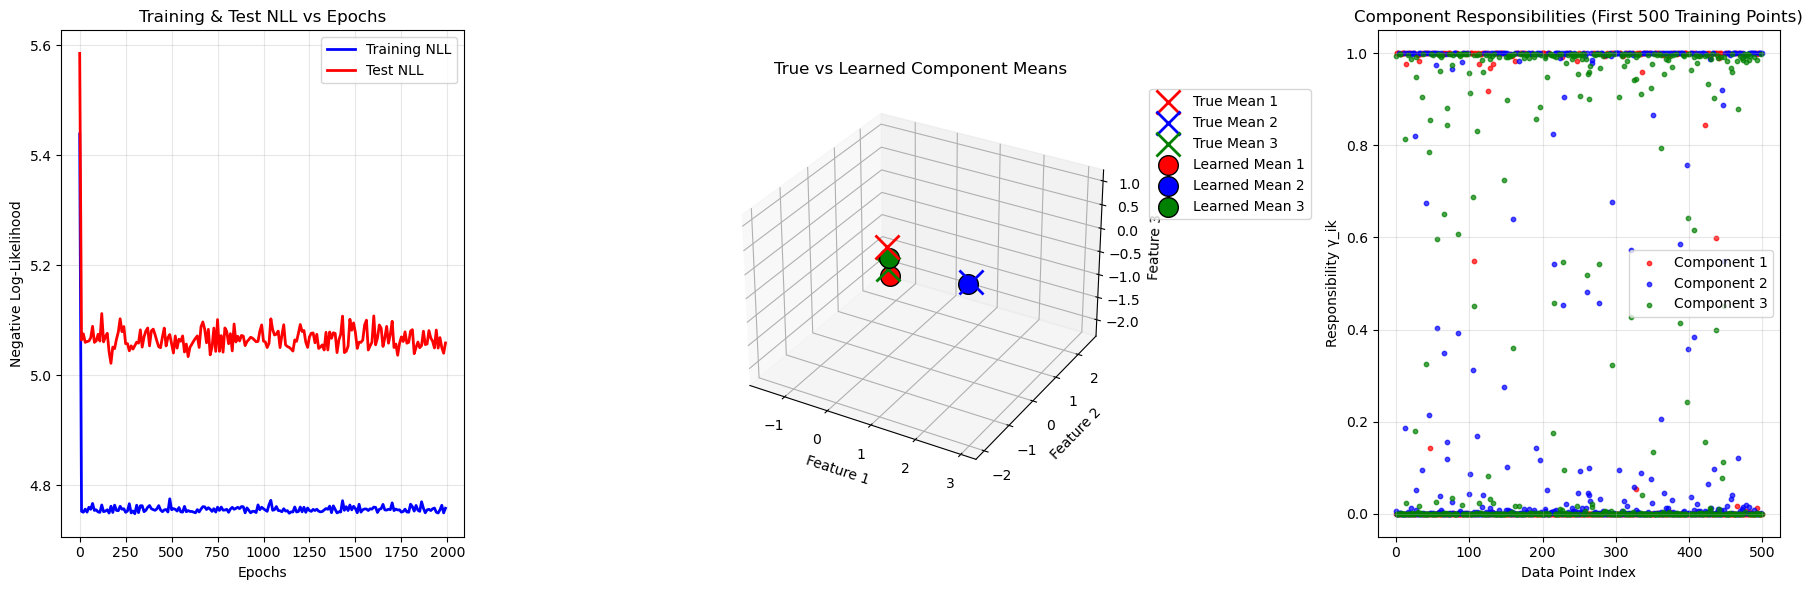

In [321]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Available device: {device}")

# Run the complete training pipeline
mog_model, train_losses, test_losses = run_mog_sgd_learning(
    X_train, X_test, mixing_weights, means, covariance_diagonals, device=device
)

Final Performance Assessment
Results with proper component matching:

Mixing weights MSE: 0.000810
Means MSE: 0.014637
Variances MSE: 0.020867 

Initially I did not implement component matching, and that was causing my MSE to be around 3. This is a drastic improvement.

I had also faced numerous setbacks with setting up the parameters correctly.